# Урок 1.2. Функции потерь и лучшая константа

**Интерактивная версия:** `lessons/lesson_1_2/web/index.html`

1. Четыре функции потерь и их градиенты.
2. Лучшая константа: численно и по формулам (среднее, медиана, квантиль).
3. Влияние выбросов.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import get_loss
from gbcourse.plotting import use_course_style, plot_loss_functions

use_course_style()

## 1. Формы потерь и их градиентов

Слева — $L(r)$, справа — антиградиент $-\partial L / \partial F$ как функция остатка $r = y - F$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


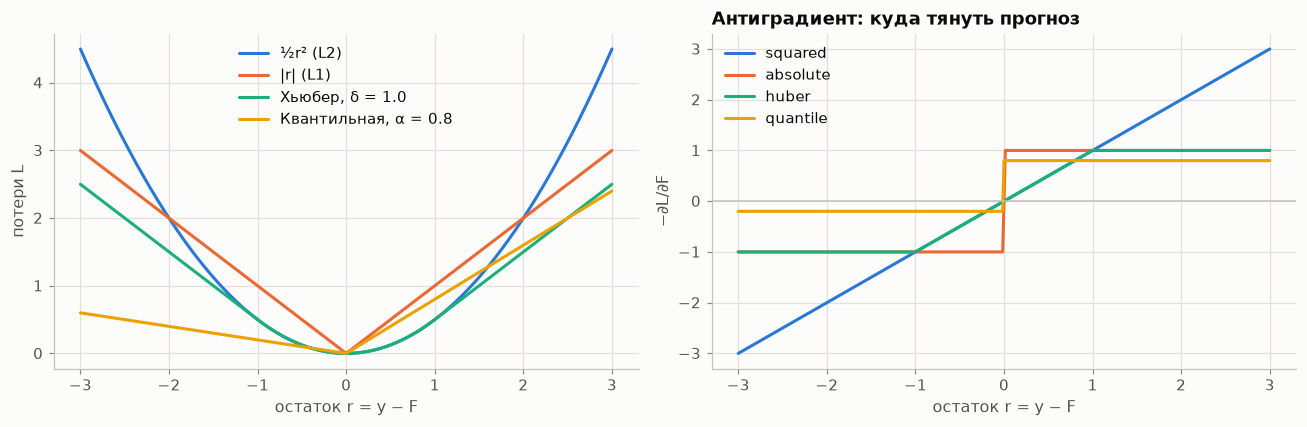

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_loss_functions(axes[0], names=("squared", "absolute", "huber", "quantile"), delta=1.0, alpha=0.8)
r = np.linspace(-3, 3, 401)
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.8})]:
    loss = get_loss(name, **kw)
    axes[1].plot(r, loss.negative_gradient(r, np.zeros_like(r)), label=name)
axes[1].axhline(0, color="#c3c2b7", lw=1)
axes[1].set(xlabel="остаток r = y − F", ylabel="−∂L/∂F", title="Антиградиент: куда тянуть прогноз")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Лучшая константа

Найдём $\arg\min_c \sum_i L(y_i, c)$ перебором и сравним с формулами.

In [3]:
y = np.array([2.1, 2.9, 3.3, 3.8, 4.1, 4.4, 4.9, 5.6, 6.2])
cs = np.linspace(0, 12, 12001)


def best_constant(loss, y):
    total = np.array([loss.pointwise(y, np.full_like(y, c)).sum() for c in cs])
    return cs[int(np.argmin(total))], total


for name, kw, formula in [("squared", {}, y.mean()), ("absolute", {}, np.median(y)),
                          ("quantile", {"alpha": 0.9}, np.quantile(y, 0.9))]:
    c, _ = best_constant(get_loss(name, **kw), y)
    print(f"{name:9s}: перебор c* = {c:.3f}   формула = {formula:.3f}")

squared  : перебор c* = 4.144   формула = 4.144
absolute : перебор c* = 4.100   формула = 4.100
quantile : перебор c* = 6.200   формула = 5.720


Для квантильных потерь минимум — целый отрезок между соседними точками (функция кусочно-линейна),
поэтому перебор может вернуть любую точку отрезка — все они оптимальны.

## 3. Выброс: среднее уезжает, медиана стоит

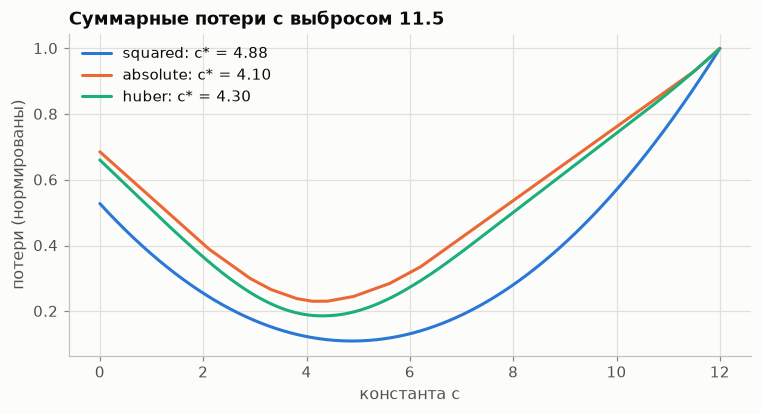

среднее без выброса 4.14 → с выбросом 4.88
медиана без выброса 4.10 → с выбросом 4.25


In [4]:
y_out = np.append(y, 11.5)
fig, ax = plt.subplots(figsize=(8, 3.8))
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0})]:
    loss = get_loss(name, **kw)
    c, total = best_constant(loss, y_out)
    ax.plot(cs, total / total.max(), label=f"{name}: c* = {c:.2f}")
ax.set(xlabel="константа c", ylabel="потери (нормированы)", title="Суммарные потери с выбросом 11.5")
ax.legend()
plt.show()
print(f"среднее без выброса {y.mean():.2f} → с выбросом {y_out.mean():.2f}")
print(f"медиана без выброса {np.median(y):.2f} → с выбросом {np.median(y_out):.2f}")

## Упражнения

1. Докажите (или проверьте численно), что при чётном $n$ сумма $\sum|y_i - c|$ постоянна между двумя центральными значениями.
2. Для потерь Хьюбера найдите оптимальную константу перебором при δ = 0.1, 1, 10. К чему она стремится при малом и большом δ?
3. Постройте зависимость 0.9-квантиля и среднего от величины выброса (от 6 до 100).

Решения: `python lessons/lesson_1_2/exercises/solutions.py`.